In [2]:
!pip install opendatasets --quiet

In [ ]:
import opendatasets as od

# KGAT_a95c8fed24b45d606a9c5d22d0abc533
# muhammadinam786

od.download('https://www.kaggle.com/datasets/mssmartypants/rice-type-classification')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: 
Your Kaggle username:

## Imports the librarys and utilitis.



In [ ]:
import torch # Torch main framework
import torch.nn as nn # Used for getting the NN Layers
from torch.optim import Adam # Adam Optimizer
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creatning the objects
from torchsummary import summary # Visualize the model layers and number of parameters
from sklearn.model_selection import train_test_split # Split the dataset (train, validation, test)
from sklearn.metrics import accuracy_score # Calculate the testing Accuracy
import matplotlib.pyplot as plt # Plotting the training progress at the end
import pandas as pd # Data reading and preprocessing
import numpy as np # Mathematical operations

device = 'cuda' if torch.cuda.is_available() else 'cpu' # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac


In [ ]:
device

In [ ]:
data_df=pd.read_csv("/content/rice-type-classification/riceClassification.csv")
data_df.head()

In [ ]:
data_df.isnull().sum()

In [ ]:
data_df.info()

In [ ]:
data_df.drop(['id'], axis=1, inplace=True)

In [ ]:
data_df.head()

In [ ]:
original_data=data_df.copy()

In [ ]:
for column in data_df.columns:
    data_df[column] = data_df[column]/data_df[column].max()

In [ ]:
data_df.head(5)

In [ ]:
X=np.array(data_df.iloc[:, :-1])
Y=np.array(data_df.iloc[:, -1])

In [ ]:
# Now training and testing data split now
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
X_test, X_val, Y_test, Y_val = train_test_split(X_test,Y_test, test_size=0.5, random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)
print(Y_train.shape)
print(Y_test.shape)
print(Y_val.shape)

This data type numpy object how to read the pytorch the data.

In [ ]:
class dataset(Dataset):
  def __init__(self, X,Y):
    self.X= torch.tensor(X, dtype=torch.float32).to(device)
    self.Y= torch.tensor(Y, dtype=torch.float32).to(device)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, index):
    return self.X[index], self.Y[index]


In [ ]:
training_data=dataset(X,Y)
testing_data=dataset(X_test,Y_test)
validating_data=dataset(X_val,Y_val)

In [ ]:
training_data.X.shape

In [ ]:
# DataLoader is create a batch size data
"""
batch_size=32 , 8
shuffle=bool
num_worker = int {multi-process loading enable karta hai (CPU ↔ RAM transfer parallel}
pin_memory=bool GPU trandfer speed BOOSTER
collate_fn se custom batching logic lagaya ja sakta hai (e.g., variable length sequences
"""

training_dataLoader=DataLoader(training_data,batch_size=8, shuffle=True, pin_memory=True)
testing_dataLoader=DataLoader(testing_data,batch_size=8, shuffle=True, pin_memory=True)
validation_dataLoader=DataLoader(validating_data,batch_size=8, shuffle=True)


In [ ]:
for i in validation_dataLoader:
  # print(i)
  print(i)
  print('======')
  break

In [ ]:
# now create a class MyModel to define forward , backward propogation functions and Neural Network code
HIDDEN_NEURONS=10
class MyModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.inputLayer = nn.Linear(X.shape[1], HIDDEN_NEURONS)
    self.linear = nn.Linear(HIDDEN_NEURONS, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
      x = self.inputLayer(x)
      x = self.linear(x)
      x = self.sigmoid(x)
      return x



model=MyModel().to(device)




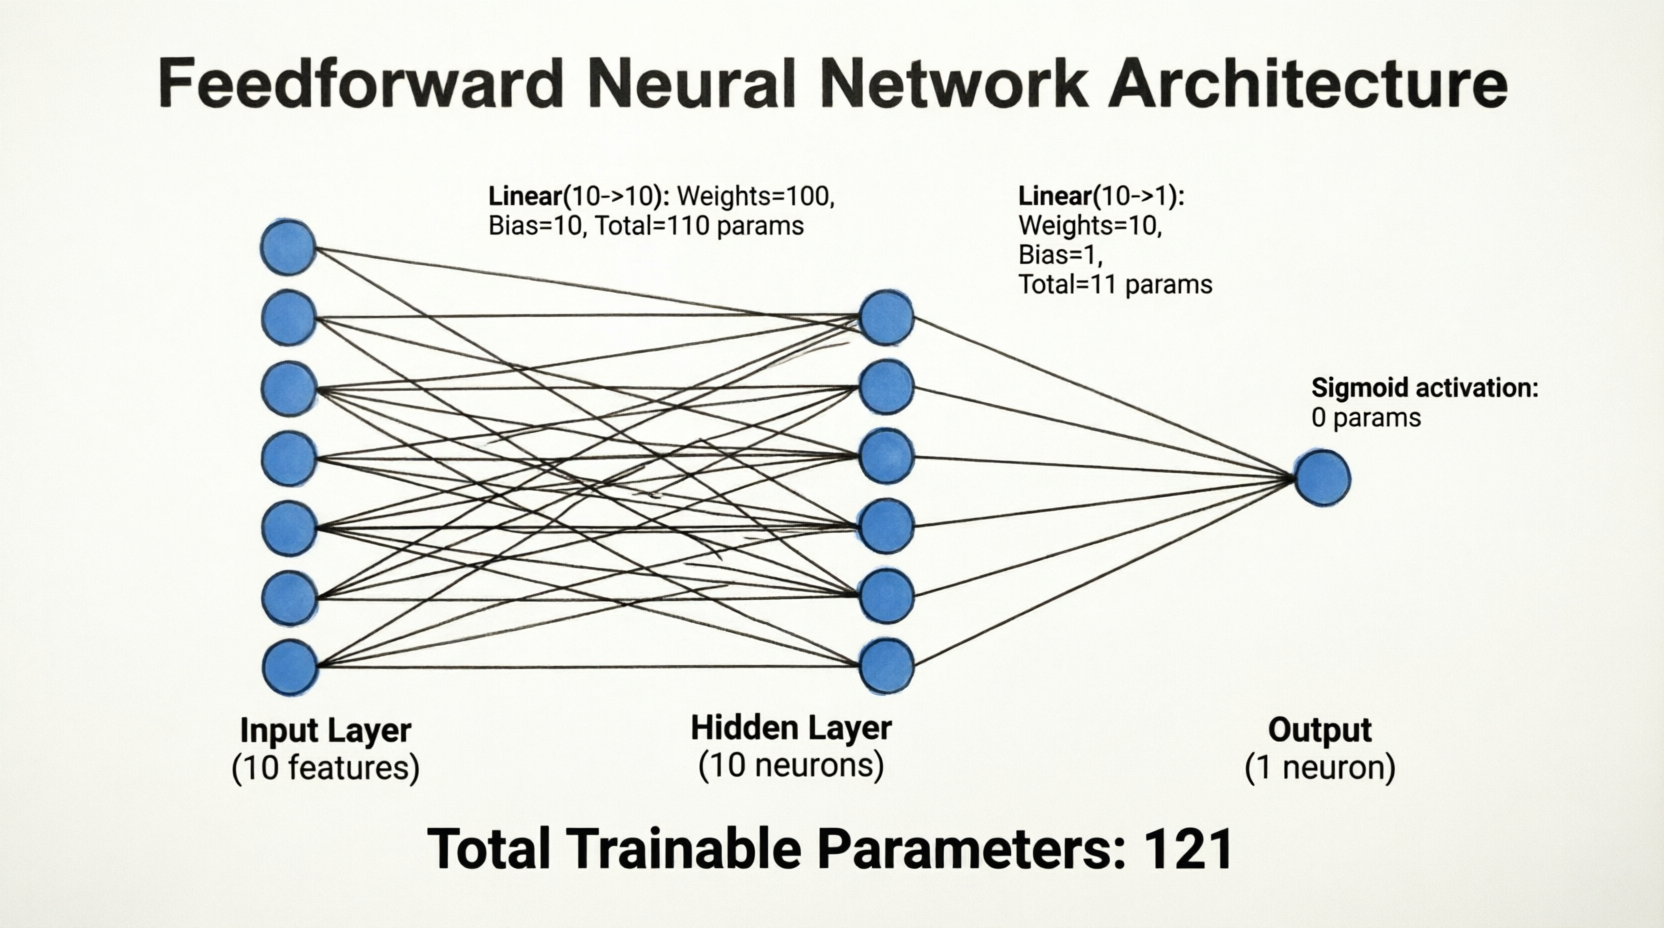

In [ ]:
summary(model, (X.shape[1],))

In [ ]:
# now define the loss funstion and optimizer

criterion = nn.BCELoss()
optimizer=Adam(model.parameters(), lr=1e-3)

In [ ]:
for i in model.parameters():
  print(i)
  break